# Week 2 - Regularized Regression: Ridge, Lasso, and Elastic Net

Week 1 left both regression models with many features and clear multicollinearity. Regularization is the
standard remedy. I apply ridge (L2), lasso (L1), and elastic net to both targets:

* Dataset A - Credit card: predict `log(transaction amount)`.
* Dataset B - UNSW-NB15: predict `log(flow duration)`.

Ridge shrinks coefficients without removing them, lasso can zero features out, and elastic net blends the two. All penalties need standardized features and a
penalty strength chosen by cross-validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
RNG = 42

cc = pd.read_csv("data/credit_card_fraud_dataset.csv")
cc["log_amount"] = np.log1p(cc["transaction_amount_usd"])
cc_continuous = ["credit_utilization_pct", "avg_monthly_spend_usd", "annual_income_usd",
                 "credit_limit_usd", "distance_from_home_km", "num_transactions_last_30d",
                 "age", "credit_score", "account_age_months", "velocity_last_1h"]
cc_binary = ["is_international_transaction", "is_new_merchant", "is_night_transaction",
             "card_present", "cvv_mismatch", "device_changed"]
cc_categorical = ["merchant_category", "device_type", "occupation"]
cc_clf_feats = ["cvv_mismatch", "prev_fraud_flags", "failed_attempts_last_24h", "device_changed",
                "is_international_transaction", "is_new_merchant", "card_present",
                "is_night_transaction", "velocity_last_1h", "credit_utilization_pct",
                "transaction_amount_usd", "distance_from_home_km", "num_transactions_last_30d",
                "age", "credit_score"]

def cc_regression_design():
    X = pd.concat([
        cc[cc_continuous].reset_index(drop=True),
        cc[cc_binary].reset_index(drop=True).astype(float),
        pd.get_dummies(cc[cc_categorical], drop_first=True).reset_index(drop=True).astype(float),
    ], axis=1)
    return X, cc["log_amount"].values

def cc_classification_design():
    return cc[cc_clf_feats].copy(), cc["is_fraud"].values

unsw_full = pd.read_parquet("data_unsw/UNSW_NB15_training-set.parquet")
unsw = unsw_full.groupby("label", group_keys=False).sample(frac=50000/len(unsw_full), random_state=RNG)
unsw = unsw.reset_index(drop=True)
unsw["log_dur"] = np.log1p(unsw["dur"].clip(lower=0))
_top_proto = unsw["proto"].value_counts().head(6).index
unsw["proto_grp"] = np.where(unsw["proto"].isin(_top_proto), unsw["proto"].astype(str), "other")
unsw_cats = ["service", "state", "proto_grp"]
unsw_numeric = [c for c in unsw.select_dtypes(include=[np.number]).columns
                if c not in ("label", "dur", "log_dur")]

def _unsw_dummies():
    return pd.get_dummies(unsw[unsw_cats].astype(str), drop_first=True).reset_index(drop=True).astype(float)

def unsw_regression_design():
    X = pd.concat([unsw[unsw_numeric].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["log_dur"].values

def unsw_classification_design():
    num = [c for c in unsw.select_dtypes(include=[np.number]).columns if c not in ("label", "log_dur")]
    X = pd.concat([unsw[num].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["label"].values

print("Credit card:", cc.shape, "| fraud rate", round(cc.is_fraud.mean(), 3))
print("UNSW sample:", unsw.shape, "| attack rate", round(unsw.label.mean(), 3))


Credit card: (55000, 30) | fraud rate 0.038
UNSW sample: (50000, 38) | attack rate 0.681


In [2]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

def run_regularizers(X, y, name):
    Xtr, Xte, ytr, yte = train_test_split(X.values, y, test_size=0.25, random_state=RNG)
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    models = {
        "OLS": LinearRegression(),
        "Ridge": RidgeCV(alphas=np.logspace(-3, 4, 30)),
        "Lasso": LassoCV(n_alphas=25, cv=4, max_iter=8000, random_state=RNG),
        "ElasticNet": ElasticNetCV(l1_ratio=[0.2, 0.6, 0.9], n_alphas=25, cv=4, max_iter=8000, random_state=RNG),
    }
    rows, coefs = {}, {}
    for mname, m in models.items():
        m.fit(Xtr_s, ytr); pred = m.predict(Xte_s)
        c = getattr(m, "coef_", np.zeros(Xtr_s.shape[1]))
        rows[mname] = {"test_R2": round(r2_score(yte, pred), 3),
                       "test_RMSE": round(root_mean_squared_error(yte, pred), 3),
                       "nonzero": int(np.sum(np.abs(c) > 1e-6)),
                       "alpha": round(getattr(m, "alpha_", np.nan), 4) if hasattr(m, "alpha_") else np.nan}
        coefs[mname] = pd.Series(c, index=X.columns)
    print(f"=== {name} (p={X.shape[1]}) ===")
    print(pd.DataFrame(rows).T.to_string())
    return pd.DataFrame(rows).T, coefs

def with_poly(X, subset):
    pf = PolynomialFeatures(2, include_bias=False); a = pf.fit_transform(X[subset])
    nm = pf.get_feature_names_out(subset); keep = [i for i, n in enumerate(nm) if "^2" in n or " " in n]
    ex = pd.DataFrame(a[:, keep], columns=[nm[i] for i in keep])
    return pd.concat([X.reset_index(drop=True), ex.reset_index(drop=True)], axis=1)

## Dataset A - Credit card: regularizing the amount model

I use the full engineered design from Week 1 then compare ordinary least squares with the three regularizers.

In [3]:
ccX, ccy = cc_regression_design()
ccX = with_poly(ccX, ["credit_utilization_pct", "avg_monthly_spend_usd",
                      "distance_from_home_km", "num_transactions_last_30d"])
cc_tab, cc_coef = run_regularizers(ccX, ccy, "Credit card - log(amount)")
cc_tab

=== Credit card - log(amount) (p=54) ===
            test_R2  test_RMSE  nonzero    alpha
OLS           0.875      0.433     54.0      NaN
Ridge         0.875      0.433     54.0  12.6896
Lasso         0.875      0.433     45.0   0.0008
ElasticNet    0.875      0.433     45.0   0.0008


,test_R2,test_RMSE,nonzero,alpha
OLS,0.875,0.433,54.0,NaN
Ridge,0.875,0.433,54.0,12.6896
Lasso,0.875,0.433,45.0,0.0008
ElasticNet,0.875,0.433,45.0,0.0008


In [4]:
# How many features does lasso drop, and which strong ones survive?
dropped = cc_coef["Lasso"][cc_coef["Lasso"].abs() <= 1e-6].index.tolist()
print(f"Lasso zeroed {len(dropped)} of {ccX.shape[1]} features.")
print("Top features kept by Lasso:")
print(cc_coef["Lasso"][cc_coef["Lasso"].abs() > 1e-6].abs().sort_values(ascending=False).head(6).round(3))

Lasso zeroed 9 of 54 features.
Top features kept by Lasso:
num_transactions_last_30d      0.962
avg_monthly_spend_usd          0.759
credit_utilization_pct         0.539
num_transactions_last_30d^2    0.444
avg_monthly_spend_usd^2        0.422
credit_utilization_pct^2       0.327
dtype: float64


For credit card the four models land at essentially the same test R². With 55,000 rows
and moderate collinearity, ordinary least squares is not overfitting so regularization buys
simplicity and stability rather than accuracy. Lasso produces the leanest model by zeroing
the weakest and most redundant features while
ridge keeps all features but shrinks that collinear group.

## Dataset B - UNSW: regularizing the duration model

UNSW is where regularization should matter most. Week 1 showed near-perfect collinearity. With ordinary least
squares those redundant features make individual coefficients wild and unstable. I examine
how each penalty responds.

In [5]:
uX, uy = unsw_regression_design()
u_tab, u_coef = run_regularizers(uX, uy, "UNSW - log(dur)")
u_tab

=== UNSW - log(dur) (p=54) ===
            test_R2  test_RMSE  nonzero   alpha
OLS           0.649      0.385     54.0     NaN
Ridge         0.650      0.385     54.0  1.3738
Lasso         0.650      0.385     46.0  0.0003
ElasticNet    0.650      0.385     47.0  0.0003


,test_R2,test_RMSE,nonzero,alpha
OLS,0.649,0.385,54.0,NaN
Ridge,0.650,0.385,54.0,1.3738
Lasso,0.650,0.385,46.0,0.0003
ElasticNet,0.650,0.385,47.0,0.0003


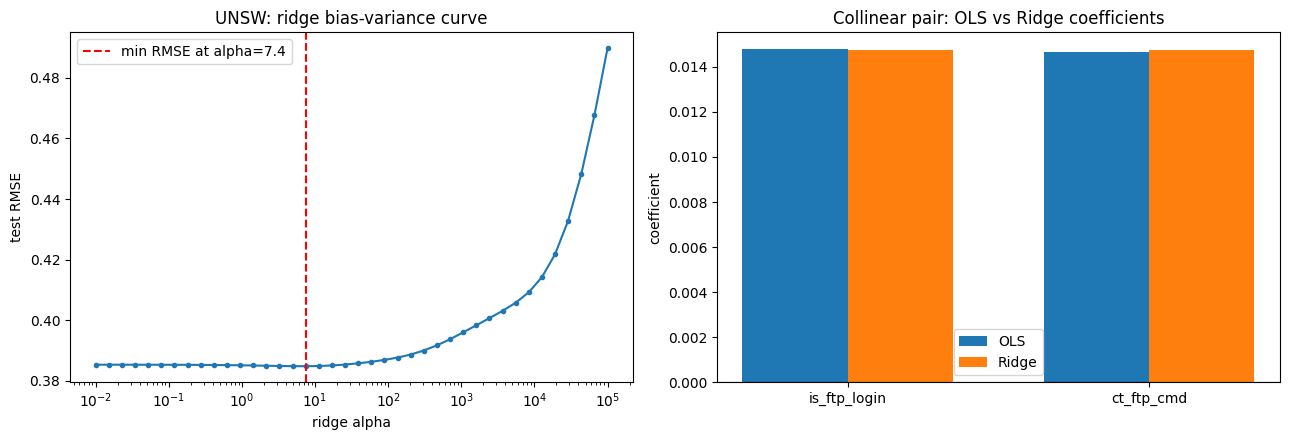

OLS coefs on the identical pair: [0.015 0.015]  (sum 0.029 ) arbitrary split
Ridge coefs on the identical pair: [0.015 0.015]  shared evenly
Lasso zeroed 8 of 54 UNSW features.


In [6]:
from sklearn.linear_model import Ridge
Xtr, Xte, ytr, yte = train_test_split(uX.values, uy, test_size=0.25, random_state=RNG)
sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
alphas = np.logspace(-2, 5, 40)
rmses = [root_mean_squared_error(yte, Ridge(alpha=a).fit(Xtr_s, ytr).predict(Xte_s)) for a in alphas]
best_a = alphas[int(np.argmin(rmses))]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].semilogx(alphas, rmses, marker=".")
ax[0].axvline(best_a, color="red", ls="--", label=f"min RMSE at alpha={best_a:.1f}")
ax[0].set_xlabel("ridge alpha"); ax[0].set_ylabel("test RMSE"); ax[0].set_title("UNSW: ridge bias-variance curve"); ax[0].legend()

pair = ["is_ftp_login", "ct_ftp_cmd"]
idx = [list(uX.columns).index(p) for p in pair]
ols_c = LinearRegression().fit(Xtr_s, ytr).coef_[idx]
rid_c = Ridge(alpha=best_a).fit(Xtr_s, ytr).coef_[idx]
xb = np.arange(2); w = 0.35
ax[1].bar(xb - w/2, ols_c, w, label="OLS"); ax[1].bar(xb + w/2, rid_c, w, label="Ridge")
ax[1].set_xticks(xb); ax[1].set_xticklabels(pair); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_ylabel("coefficient"); ax[1].set_title("Collinear pair: OLS vs Ridge coefficients"); ax[1].legend()
plt.tight_layout(); plt.show()
print("OLS coefs on the identical pair:", np.round(ols_c, 3), " (sum",
      round(ols_c.sum(), 3), ") arbitrary split")
print("Ridge coefs on the identical pair:", np.round(rid_c, 3), " shared evenly")
print(f"Lasso zeroed {int((u_coef['Lasso'].abs()<=1e-6).sum())} of {uX.shape[1]} UNSW features.")

The left panel is the classic
bias-variance curve: test RMSE falls as ridge `alpha` rises from near zero, bottoms out, then
climbs again once the penalty over-shrinks. Cross-validation picks the bottom of that valley.
The right panel is more subtle. On the perfectly collinear `is_ftp_login`
/ `ct_ftp_cmd` pair, ordinary least squares does not explode. Scikit-learn's SVD-based solver already splits the weight evenly.
So on this data regularization's value is not taming wild coefficients but first locating the
bias-variance optimum and second sparsity. Lasso zeroes out several redundant byte/packet/loss
features for a leaner model at the same accuracy. The infinite VIF still flags the perfect
redundancy.

## Conclusions

* Regularization preserves accuracy and buys stability on both datasets. Ridge, lasso, and
  elastic net all match OLS in test R² because both datasets are
  large enough to fit OLS, so the value is in the coefficients, not the score.
* The benefit is mainly sparsity, and it is larger for UNSW whose severe redundancy lets
  lasso drop the most features. Ridge and even SVD-based OLS already share weight sensibly across
  the identical columns so the practical payoff is a simpler easier-to-explain model.
* Lasso gives the most parsimonious model on both targets which is useful for explaining the
  drivers of transaction amount and flow duration to a non-technical stakeholder.
